# Udemy Project (Competition Analysis)

## Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

## Loading & Inspecting Dataset

In [2]:
df = pd.read_csv('udemy_courses.csv')
df.head()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [4]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
course_id,3678.0,675971.96,343273.16,8324.0,407692.5,687917.0,961355.50,1282064.0
price,3678.0,66.05,61.01,0.0,20.0,45.0,95.00,200.0
num_subscribers,3678.0,3197.15,9504.12,0.0,111.0,911.5,2546.00,268923.0
num_reviews,3678.0,156.26,935.45,0.0,4.0,18.0,67.00,27445.0
num_lectures,3678.0,40.11,50.38,0.0,15.0,25.0,45.75,779.0
content_duration,3678.0,4.09,6.05,0.0,1.0,2.0,4.50,78.5


In [5]:
df.shape

(3678, 12)

## Data Preprocessing
- **Missing Values**
- **Duplicated Records**
- **Outliers**
- **Data Manipulation**
- **Invalid Values**



In [6]:
df.isna().sum()

course_id              0
course_title           0
url                    0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(6)

In [8]:
df.drop_duplicates(inplace = True)

In [9]:
df.columns

Index(['course_id', 'course_title', 'url', 'is_paid', 'price',
       'num_subscribers', 'num_reviews', 'num_lectures', 'level',
       'content_duration', 'published_timestamp', 'subject'],
      dtype='object')

<Axes: >

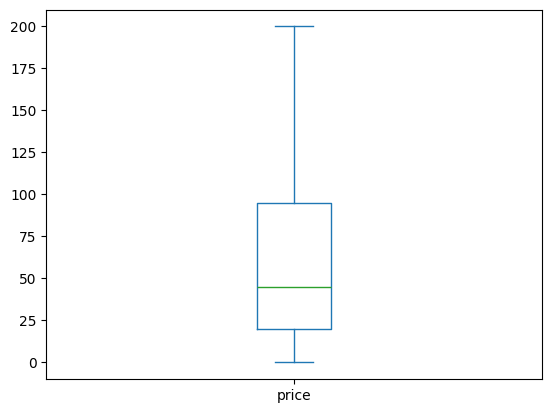

In [10]:
df['price'].plot(kind='box')

<Axes: >

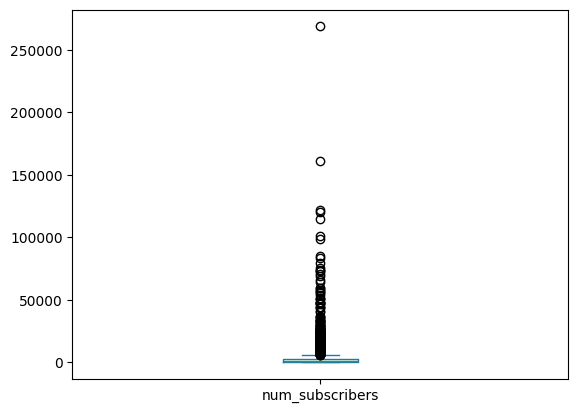

In [11]:
df['num_subscribers'].plot(kind='box')

In [12]:
q1 = df['num_subscribers'].quantile(0.25)
q3 = df['num_subscribers'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.3 * IQR
upper_margin = q3 + 1.3 * IQR

df = df[(df['num_subscribers'] >= lower_margin) & (df['num_subscribers'] <= upper_margin)]

<Axes: >

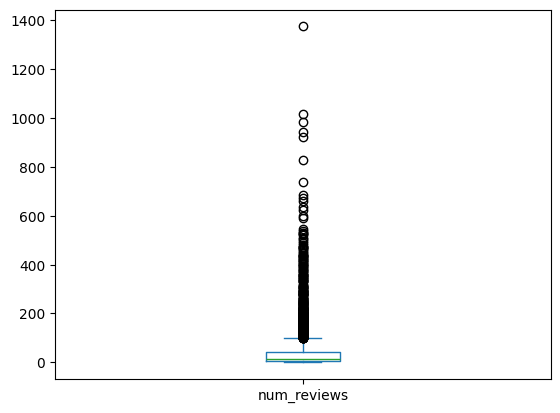

In [13]:
df['num_reviews'].plot(kind= 'box')

In [14]:
q1 = df['num_reviews'].quantile(0.25)
q3 = df['num_reviews'].quantile(0.75)

IQR = q3 - q1

lower_margin = q1 - 1.3 * IQR
upper_margin = q3 + 1.3 * IQR

df = df[(df['num_reviews'] >= lower_margin) & (df['num_reviews'] <= upper_margin)]

In [15]:
df['published_timestamp'].info()

<class 'pandas.core.series.Series'>
Index: 2783 entries, 0 to 3677
Series name: published_timestamp
Non-Null Count  Dtype 
--------------  ----- 
2783 non-null   object
dtypes: object(1)
memory usage: 43.5+ KB


In [16]:
df['published_timestamp'] = pd.to_datetime(df['published_timestamp']).dt.date

In [18]:
df['published_timestamp']

0       2017-01-18
2       2016-12-19
3       2017-05-30
4       2016-12-13
8       2015-05-28
           ...    
3672    2016-10-10
3673    2016-06-14
3674    2017-03-10
3676    2016-08-11
3677    2014-09-28
Name: published_timestamp, Length: 2783, dtype: object

In [19]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
course_id,2783.0,701731.74,342484.58,12214.0,444114.0,720072.0,990486.0,1282064.0
price,2783.0,61.03,56.07,0.0,20.0,40.0,80.0,200.0
num_subscribers,2783.0,884.45,1128.32,0.0,57.0,394.0,1311.0,5715.0
num_reviews,2783.0,17.88,20.44,0.0,3.0,10.0,26.0,91.0
num_lectures,2783.0,33.20,38.19,0.0,13.0,23.0,39.0,462.0
content_duration,2783.0,3.23,4.39,0.0,1.0,2.0,3.5,70.0


In [20]:
# remove invalid values.
df = df[ (df['num_lectures'] > 0) & (df['content_duration'] > 0) ] 

In [21]:
df.shape

(2782, 12)

In [22]:
df = df.reset_index(drop= True)

In [23]:
df.head(1)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18,Business Finance


In [24]:
df['subject'].value_counts()

subject
Business Finance       1032
Musical Instruments     629
Web Development         605
Graphic Design          516
Name: count, dtype: int64

In [25]:
df['level'].value_counts()

level
All Levels            1440
Beginner Level         959
Intermediate Level     332
Expert Level            51
Name: count, dtype: int64

In [26]:
df['is_paid'].value_counts()

is_paid
True     2655
False     127
Name: count, dtype: int64

In [27]:
df['course_title'].value_counts()

course_title
Creating an animated greeting card via Google Slides          3
Aprende a tocar el acordeón de botones                        2
Drum Lessons For Beginners                                    2
Ultimate JavaScript Objects                                   1
HTML Forms For Beginners: A Basic Introduction                1
                                                             ..
Option Trading for Rookies:  Understand Options Completely    1
How I Learned Stock Trading (and How You Can Too)             1
Options Trading - Calendar Spread Course for Every Trader     1
A Beginner's Guide to Quantopian Futures API                  1
Python Algo Trading: Sentiment Trading with News              1
Name: count, Length: 2778, dtype: int64

In [28]:
df.rename(columns={'published_timestamp' : 'published'} , inplace= True)

In [30]:
df['published'] = pd.to_datetime(df['published'])
df['year'] = df['published'].dt.year
df['quarter'] = df['published'].dt.quarter
df['month'] = df['published'].dt.month_name()

In [31]:
df.set_index(df['published'], inplace= True)

In [32]:
df.sample()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published,subject,year,quarter,month
published,,,,,,,,,,,,,,,
2015-11-17,663702,Graphic Design: Double Your Sales With Canva,https://www.udemy.com/canva-marketing/,True,20,1797,40,39,All Levels,2.5,2015-11-17,Graphic Design,2015,4,November


In [33]:
df.columns

Index(['course_id', 'course_title', 'url', 'is_paid', 'price',
       'num_subscribers', 'num_reviews', 'num_lectures', 'level',
       'content_duration', 'published', 'subject', 'year', 'quarter', 'month'],
      dtype='object')

In [34]:
## Reorder the coulmns.
df = df[['course_id', 'course_title', 'url', 'is_paid', 'price',
       'num_subscribers', 'num_reviews', 'num_lectures', 'level',
       'content_duration','subject','published', 'year', 'quarter', 'month']]

In [35]:
df.sample(2)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month
published,,,,,,,,,,,,,,,
2015-12-06,648492,Guitar Lessons : Rock Guitar in 1 Day!,https://www.udemy.com/rock-guitar/,True,50,17,4,37,Beginner Level,1.5,Musical Instruments,2015-12-06,2015,4,December
2015-03-22,452092,Adobe Illustrator: Create a Quick & Easy Uniqu...,https://www.udemy.com/create-quick-easy-origin...,True,95,1418,57,19,Beginner Level,1.5,Graphic Design,2015-03-22,2015,1,March


In [36]:
df['price'].dtype

dtype('int64')

In [37]:
df['price'].value_counts()

price
20     740
50     390
200    194
40     188
30     142
25     139
0      127
95     118
35     104
100     84
45      70
195     66
60      53
75      51
150     44
55      32
85      26
120     26
125     23
80      23
65      22
70      21
145     17
90      14
180     12
115     10
135      7
175      7
105      6
140      4
185      4
190      3
165      3
130      3
110      3
170      3
160      2
155      1
Name: count, dtype: int64

In [38]:
df['profit'] = df['price'] * df['num_subscribers']

In [39]:
df.sample(2)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit
published,,,,,,,,,,,,,,,,
2016-12-26,1037868,Digital Pianist Course-Learn Piano & Keyboard ...,https://www.udemy.com/digital-pianist-course-l...,True,150,89,7,35,Beginner Level,3.0,Musical Instruments,2016-12-26,2016,4,December,13350
2017-02-23,1085064,Let's JavaScript! Code a calculator,https://www.udemy.com/lets-javascript-beginner...,True,35,380,10,30,Beginner Level,2.0,Web Development,2017-02-23,2017,1,February,13300


In [40]:
## To check the primary key condition and find the duplicated values.
df['course_id'].value_counts().sort_values(ascending= False)

course_id
1070968    1
1006314    1
1210588    1
1011058    1
476268     1
          ..
865438     1
775618     1
1088178    1
905096     1
297602     1
Name: count, Length: 2782, dtype: int64

In [41]:
df.sample(3)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit
published,,,,,,,,,,,,,,,,
2016-03-14,782192,Introduction to HTML5 Canvas basics of drawing,https://www.udemy.com/introduction-to-html5-ca...,True,200,2918,16,17,Beginner Level,1.0,Web Development,2016-03-14,2016,1,March,583600
2017-03-10,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.5,Web Development,2017-03-10,2017,1,March,7650
2017-03-28,1144780,Curso de batería online de Patricio Iglesias (...,https://www.udemy.com/cursodebateriaonlinedepa...,True,35,5,1,17,Intermediate Level,4.0,Musical Instruments,2017-03-28,2017,1,March,175


In [42]:
df['content_duration'].describe().round(2)

count    2782.00
mean        3.24
std         4.39
min         0.13
25%         1.00
50%         2.00
75%         3.50
max        70.00
Name: content_duration, dtype: float64

In [43]:
df['content_duration'].value_counts()

content_duration
1.0     509
1.5     414
2.0     343
2.5     218
3.0     198
       ... 
42.0      1
22.5      1
25.5      1
23.5      1
66.5      1
Name: count, Length: 80, dtype: int64

In [44]:

df['content_duration_cat'] = pd.cut(df['content_duration'] , 
       bins=[0,1,3,7,12,20,np.inf],
       labels=['0 : 1' , '1 : 3', '3 : 7' , '7 : 12' , '12 : 20' , '+20'],
       include_lowest= True)


In [45]:
df.sample(3)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat
published,,,,,,,,,,,,,,,,,
2015-10-19,638980,Option Trading: How to Adjust Delta-Neutral St...,https://www.udemy.com/option-trading-selling-s...,True,145,1398,15,26,All Levels,1.5,Business Finance,2015-10-19,2015,4,October,202710,1 : 3
2015-05-12,456388,Adobe Photoshop CC | The Essential Guide,https://www.udemy.com/adobe-photoshop-cc-the-e...,True,20,254,5,81,All Levels,4.5,Graphic Design,2015-05-12,2015,2,May,5080,3 : 7
2015-11-25,676432,Violin lessons for beginners,https://www.udemy.com/violin-lessons-for-begin...,True,20,59,6,15,Beginner Level,1.0,Musical Instruments,2015-11-25,2015,4,November,1180,0 : 1


In [46]:
df['price'].sort_values()

published
2017-03-23      0
2017-06-08      0
2017-03-30      0
2015-06-12      0
2016-04-07      0
             ... 
2017-06-11    200
2017-06-01    200
2017-01-18    200
2016-09-04    200
2016-12-13    200
Name: price, Length: 2782, dtype: int64

In [47]:
df['price'].value_counts().sort_values(ascending= False)

price
20     740
50     390
200    194
40     188
30     142
25     139
0      127
95     118
35     104
100     84
45      70
195     66
60      53
75      51
150     44
55      32
85      26
120     26
125     23
80      23
65      22
70      21
145     17
90      14
180     12
115     10
135      7
175      7
105      6
140      4
185      4
190      3
165      3
130      3
110      3
170      3
160      2
155      1
Name: count, dtype: int64

In [48]:
df['price_cat'] = pd.cut(df['price'] ,
                         bins=[-1,0,20,50,80, 110, 140,170,200], 
                         labels=['free' , '1:20' , '20:50' , '50:80', '80:110', '110:140', '140:170', '170:200']
                         )

In [49]:
df['price_cat'].value_counts()

price_cat
20:50      1033
1:20        740
170:200     286
80:110      251
50:80       202
free        127
110:140      73
140:170      70
Name: count, dtype: int64

## EDA
- **Uni-variant Analysis**
- **Bi-variant Analysis**
- **Multi-variant Analysis**

In [50]:
df.sample(2)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2017-05-19,1104500,Instant Harmonica - play 12 bar blues Big Walt...,https://www.udemy.com/instant-harmonica-play-1...,True,40,31,2,14,All Levels,1.0,Musical Instruments,2017-05-19,2017,2,May,1240,0 : 1,20:50
2013-12-13,130168,HTML and CSS for Beginning Web Developers,https://www.udemy.com/html-and-css-for-beginni...,True,100,1606,28,73,Beginner Level,9.0,Web Development,2013-12-13,2013,4,December,160600,7 : 12,80:110


### Subject

- **Uni-variant Analysis**

In [51]:
df.sample(3)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2015-09-02,342398,Learn the Violin - No Music Experience Necessary!,https://www.udemy.com/learn-the-violin-no-musi...,True,120,600,27,30,Beginner Level,3.0,Musical Instruments,2015-09-02,2015,3,September,72000,1 : 3,110:140
2016-09-01,944804,Coaching Bundle: Guitar for Music Educators: P...,https://www.udemy.com/coaching-bundle-guitar-f...,True,135,1,1,5,All Levels,0.5,Musical Instruments,2016-09-01,2016,3,September,135,0 : 1,110:140
2015-02-17,421018,Learning Object-Oriented JavaScript,https://www.udemy.com/learning-object-oriented...,True,75,533,54,23,Intermediate Level,3.0,Web Development,2015-02-17,2015,1,February,39975,1 : 3,50:80


In [52]:
df['subject'].dtype

dtype('O')

#### Subject Overview

In [53]:
df['subject'].describe(include='O')

count                 2782
unique                   4
top       Business Finance
freq                  1032
Name: subject, dtype: object

#### How many coursers in each subject?

In [54]:
df['subject'].value_counts()

subject
Business Finance       1032
Musical Instruments     629
Web Development         605
Graphic Design          516
Name: count, dtype: int64

<Axes: xlabel='subject'>

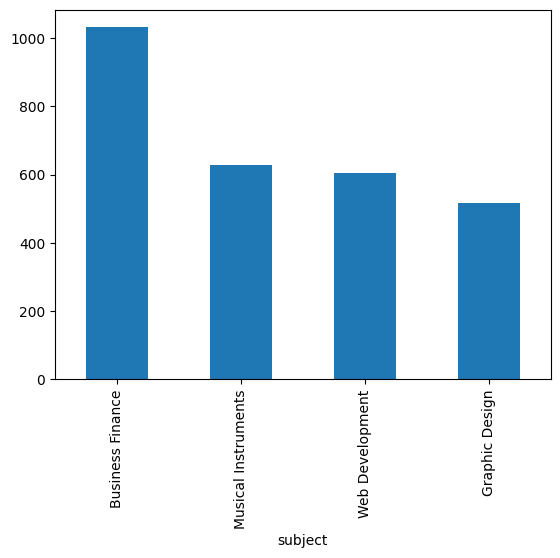

In [55]:
df['subject'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

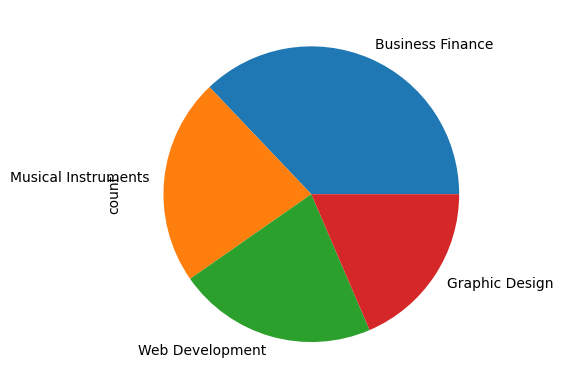

In [56]:
df['subject'].value_counts().plot(kind='pie')

#### What is the percentage of each subject?

In [57]:
round((df['subject'].value_counts() / len(df))* 100 , 2)

subject
Business Finance       37.10
Musical Instruments    22.61
Web Development        21.75
Graphic Design         18.55
Name: count, dtype: float64

<Axes: ylabel='count'>

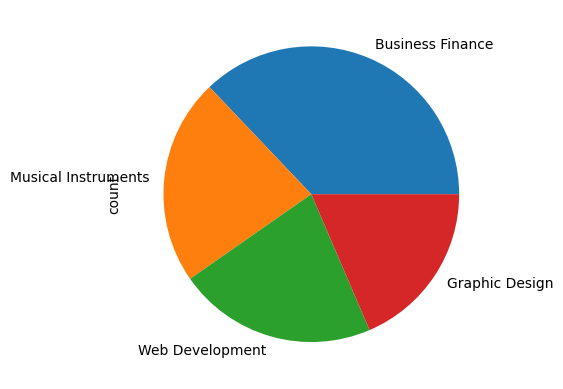

In [58]:
round((df['subject'].value_counts() / len(df))* 100 , 2).plot(kind='pie')

- **Bi-variant Analysis**

### What is the average price for each subject

In [59]:
df.groupby('subject')['price'].mean().round(2).sort_values(ascending= False)

subject
Web Development        69.69
Business Finance       67.16
Graphic Design         54.27
Musical Instruments    48.28
Name: price, dtype: float64

## How many subscribers in each subject?

In [60]:
df.groupby('subject')['num_subscribers'].sum().sort_values(ascending= False)

subject
Web Development        1022465
Business Finance        798954
Graphic Design          342119
Musical Instruments     297892
Name: num_subscribers, dtype: int64

In [61]:
fig = px.bar(
    data_frame=df.groupby('subject')['num_subscribers'].sum(),
    x = df.groupby('subject')['num_subscribers'].sum().index,
    y = df.groupby('subject')['num_subscribers'].sum().values 
    )
fig.update_xaxes(title= 'Subject')
fig.update_yaxes(title = 'Num fo Coursers')
fig.show()

### How many free courser for each subject

In [62]:
df[df['is_paid'] == False].groupby('subject').size().sort_values(ascending=False)

subject
Business Finance       53
Musical Instruments    28
Web Development        28
Graphic Design         18
dtype: int64

## In each subject what is the total courser for each level

In [63]:
df.groupby(['subject' , 'level']).size()

subject              level             
Business Finance     All Levels            604
                     Beginner Level        287
                     Expert Level           28
                     Intermediate Level    113
Graphic Design       All Levels            254
                     Beginner Level        207
                     Expert Level            5
                     Intermediate Level     50
Musical Instruments  All Levels            262
                     Beginner Level        269
                     Expert Level            6
                     Intermediate Level     92
Web Development      All Levels            320
                     Beginner Level        196
                     Expert Level           12
                     Intermediate Level     77
dtype: int64

#### In each subject how many coursers in each duration

In [64]:
df.groupby(['subject' , 'content_duration_cat']).size()

C:\Users\abdal\AppData\Local\Temp\ipykernel_14456\2171196173.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['subject' , 'content_duration_cat']).size()


subject              content_duration_cat
Business Finance     0 : 1                   292
                     1 : 3                   449
                     3 : 7                   208
                     7 : 12                   45
                     12 : 20                  18
                     +20                      20
Graphic Design       0 : 1                   178
                     1 : 3                   193
                     3 : 7                    98
                     7 : 12                   33
                     12 : 20                  12
                     +20                       2
Musical Instruments  0 : 1                   181
                     1 : 3                   298
                     3 : 7                   124
                     7 : 12                   23
                     12 : 20                   2
                     +20                       1
Web Development      0 : 1                   144
                     1 : 3 

### What is the total profit made by each subject

In [65]:
df.groupby('subject')['profit'].sum().sort_values(ascending=False)

subject
Web Development        69180930
Business Finance       53911815
Graphic Design         24517890
Musical Instruments    15578390
Name: profit, dtype: int64

- **Multi-Variant Analysis**

## How many coursers are paid and not paid in each subject?

In [66]:
df.sample()

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2015-11-17,663702,Graphic Design: Double Your Sales With Canva,https://www.udemy.com/canva-marketing/,True,20,1797,40,39,All Levels,2.5,Graphic Design,2015-11-17,2015,4,November,35940,1 : 3,1:20


In [67]:
df.groupby(['subject' , 'is_paid'])['is_paid'].size()


subject              is_paid
Business Finance     False       53
                     True       979
Graphic Design       False       18
                     True       498
Musical Instruments  False       28
                     True       601
Web Development      False       28
                     True       577
Name: is_paid, dtype: int64

In [68]:
df['subject'].value_counts()

subject
Business Finance       1032
Musical Instruments     629
Web Development         605
Graphic Design          516
Name: count, dtype: int64

#### What are the total subscribers in each level for each subjec?

In [70]:
df.groupby(['subject' , 'level'])['num_subscribers'].sum()

subject              level             
Business Finance     All Levels            492927
                     Beginner Level        218152
                     Expert Level           25683
                     Intermediate Level     62192
Graphic Design       All Levels            190667
                     Beginner Level        123834
                     Expert Level            1008
                     Intermediate Level     26610
Musical Instruments  All Levels            121049
                     Beginner Level        141428
                     Expert Level            1239
                     Intermediate Level     34176
Web Development      All Levels            537158
                     Beginner Level        375546
                     Expert Level            7396
                     Intermediate Level    102365
Name: num_subscribers, dtype: int64

### How many paid/unpaid coursers for each level in each subject?

In [71]:
df.groupby(['subject' , 'level' , 'is_paid'])['is_paid'].size()

subject              level               is_paid
Business Finance     All Levels          False       33
                                         True       571
                     Beginner Level      False       18
                                         True       269
                     Expert Level        True        28
                     Intermediate Level  False        2
                                         True       111
Graphic Design       All Levels          False        7
                                         True       247
                     Beginner Level      False       11
                                         True       196
                     Expert Level        True         5
                     Intermediate Level  True        50
Musical Instruments  All Levels          False        8
                                         True       254
                     Beginner Level      False       18
                                         True       251

#### How many courses for each subject, regarding paid/unpaid courses?

Text(0, 0.5, 'Total Courses')

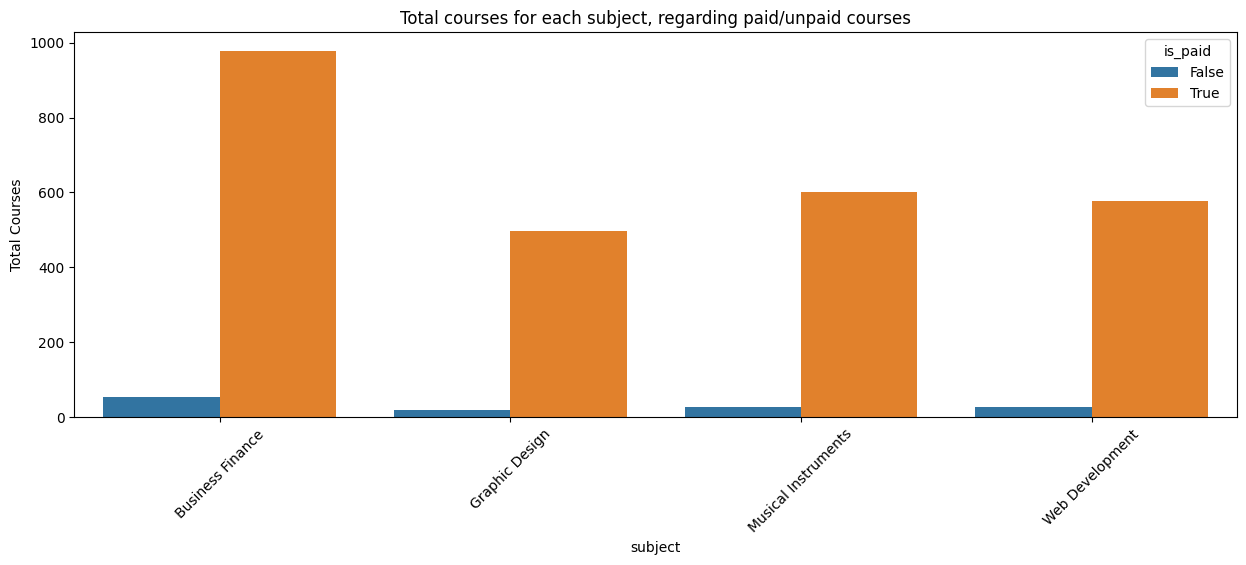

In [72]:
plt.figure(figsize=(15,5))
plt.xticks(rotation= 45)
sns.countplot(data=df ,
              x='subject',
              hue='is_paid')
plt.title('Total courses for each subject, regarding paid/unpaid courses')
plt.ylabel("Total Courses")

#### How many subscribers in each subject, regarding paid / unpaid ?

In [73]:
df_grouped = df.groupby(['subject' , 'is_paid'])['num_subscribers'].sum().reset_index()
px.bar(
    data_frame= df_grouped,
    x='subject',
    y='num_subscribers',
    color='is_paid'
)

<Axes: xlabel='subject', ylabel='count'>

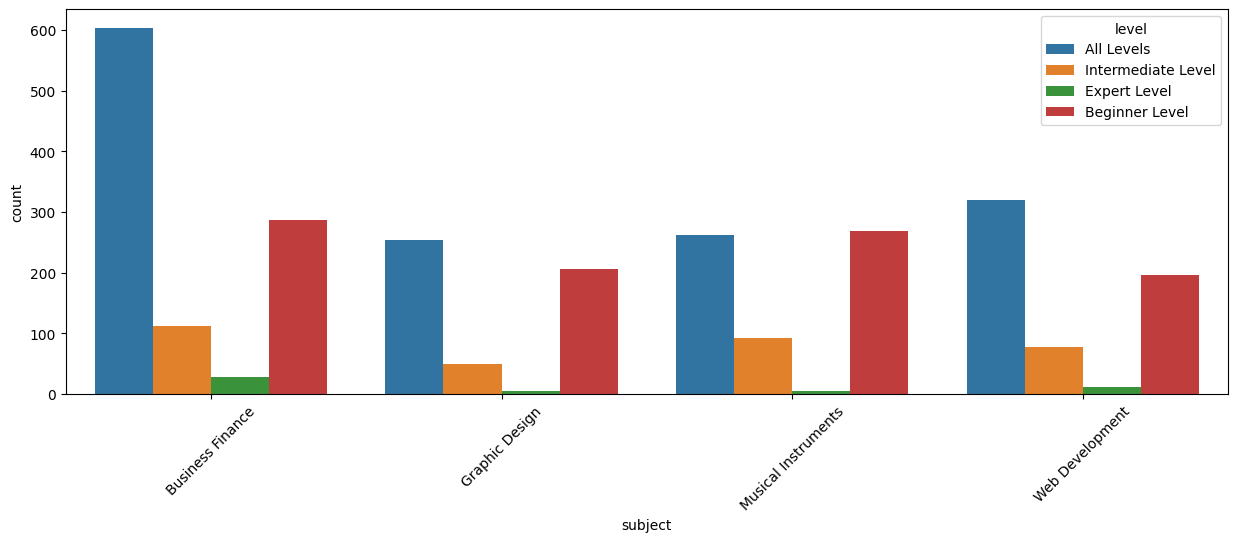

In [74]:
plt.figure(figsize=(15 , 5))
plt.xticks(rotation=45)
sns.countplot(data= df,
              x= 'subject',
              hue='level')

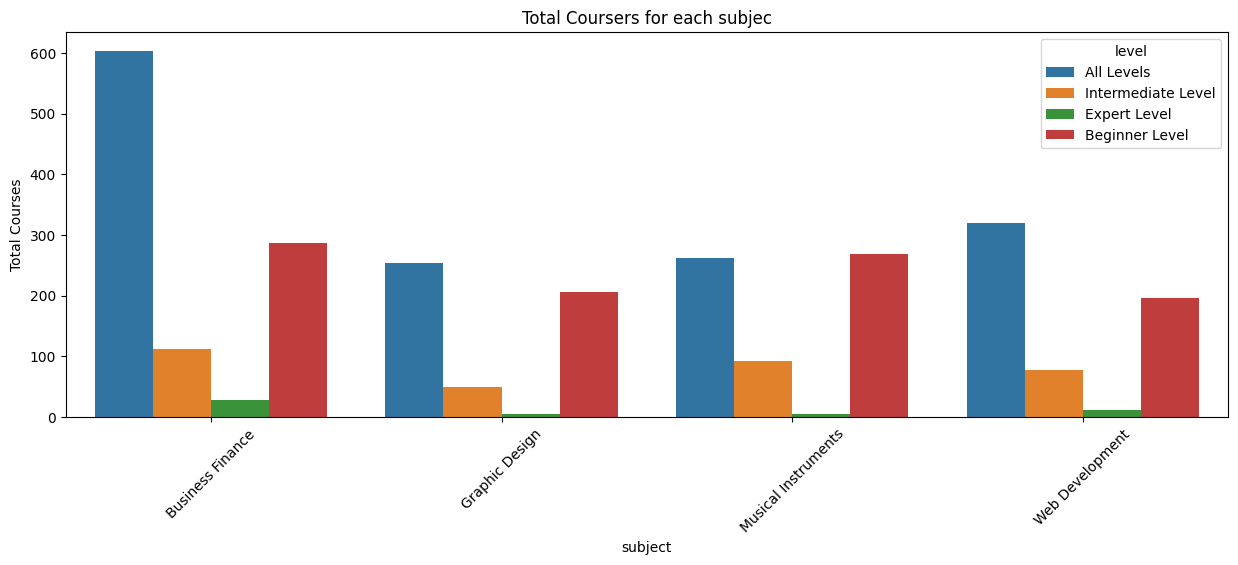

In [75]:
plt.figure(figsize=(15,5))
plt.xticks(rotation= 45)
sns.countplot(data=df , 
              x= 'subject',
              hue= 'level')
plt.title('Total Coursers for each subjec')
plt.ylabel('Total Courses')
plt.show()

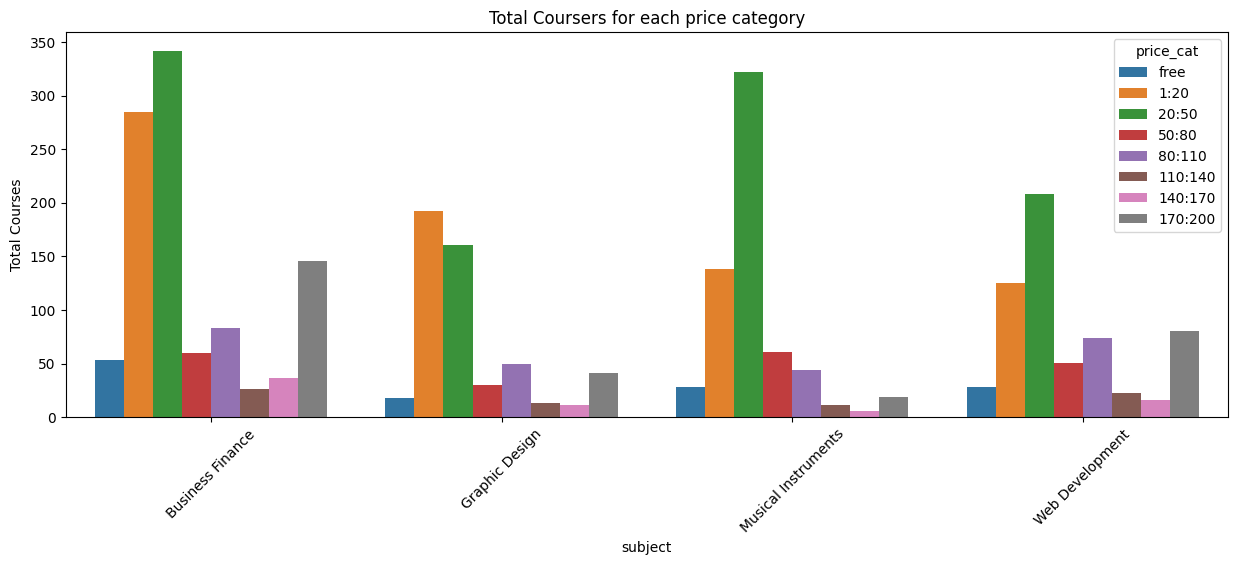

In [76]:
plt.figure(figsize=(15,5))
plt.xticks(rotation= 45)
sns.countplot(data=df , 
              x= 'subject',
              hue= 'price_cat')
plt.title('Total Coursers for each price category')
plt.ylabel('Total Courses')
plt.show()

In [77]:
df_grouped = df.groupby(['subject' , 'price_cat'])['num_subscribers'].sum().reset_index()

px.bar(data_frame=df_grouped,
       x='subject',
       y='num_subscribers',
       color='price_cat',
       title='Number subscriber in each subject, regarding price category',
       barmode='group'
       )

C:\Users\abdal\AppData\Local\Temp\ipykernel_14456\2144273534.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['subject' , 'price_cat'])['num_subscribers'].sum().reset_index()


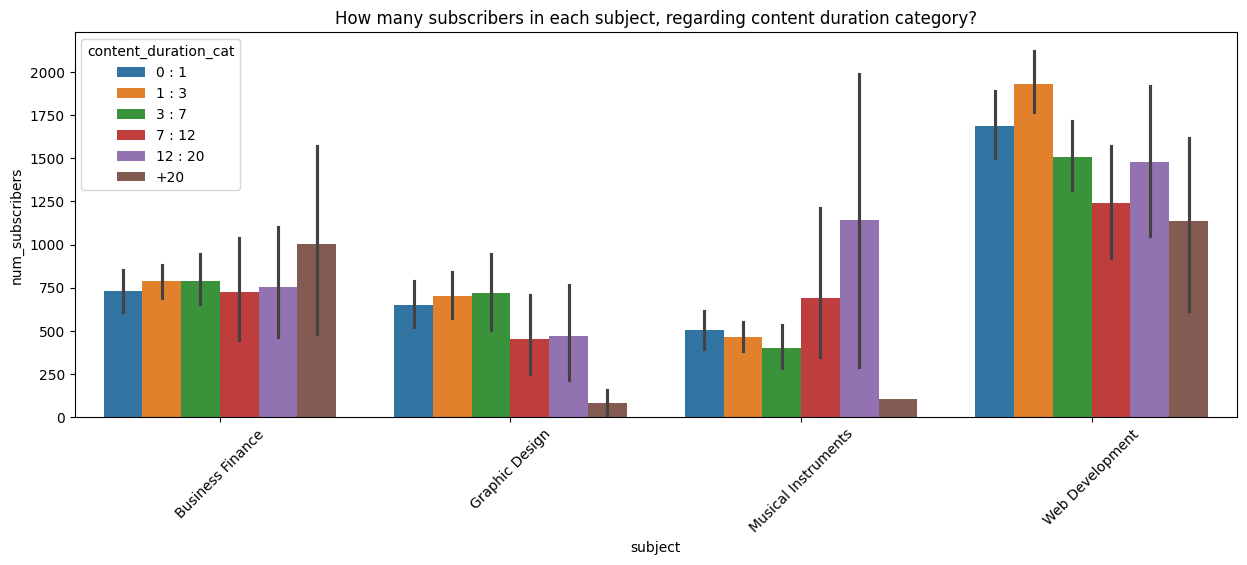

In [78]:
plt.figure(figsize=(15,5))
plt.title('How many subscribers in each subject, regarding content duration category?')
plt.xticks(rotation= 45)
sns.barplot(data=df ,
              x='subject',
              y='num_subscribers',
              hue='content_duration_cat')
plt.show()

<Axes: xlabel='subject', ylabel='profit'>

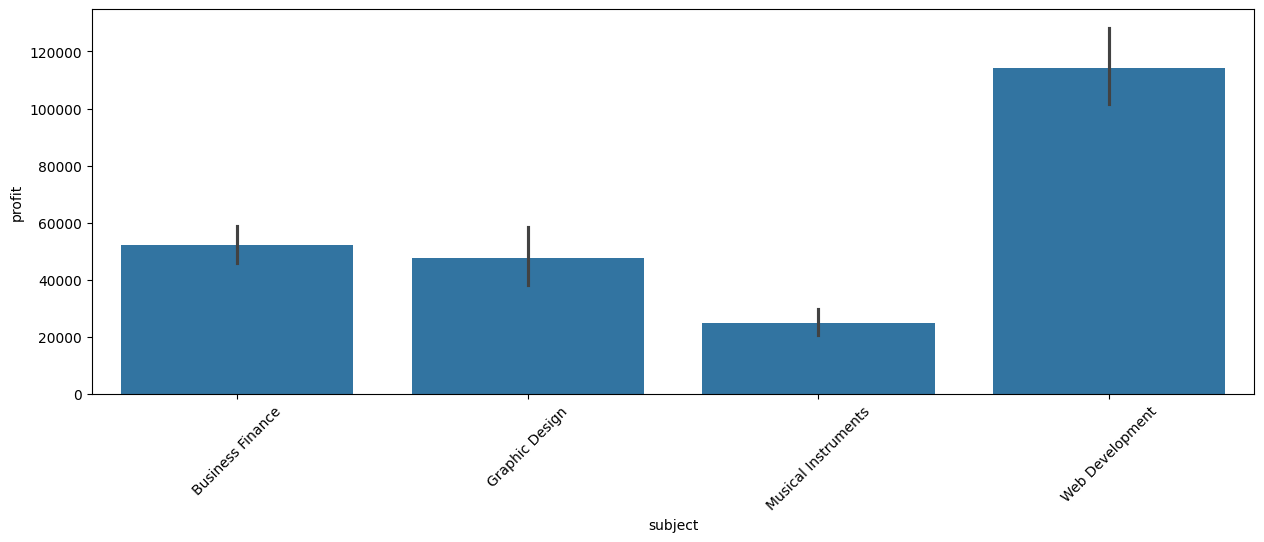

In [79]:
plt.figure(figsize=(15,5))
plt.xticks(rotation= 45)
sns.barplot(data=df,
            x='subject',
            y='profit')

In [80]:

px.bar(data_frame=df.groupby(['subject', 'year'])['profit'].sum().reset_index(),
       x='subject',
       y='profit',
       color='year',
       title='Total Profit in each subject, regarding years')

Text(0.5, 1.0, 'Total courses in each subject, regarding years')

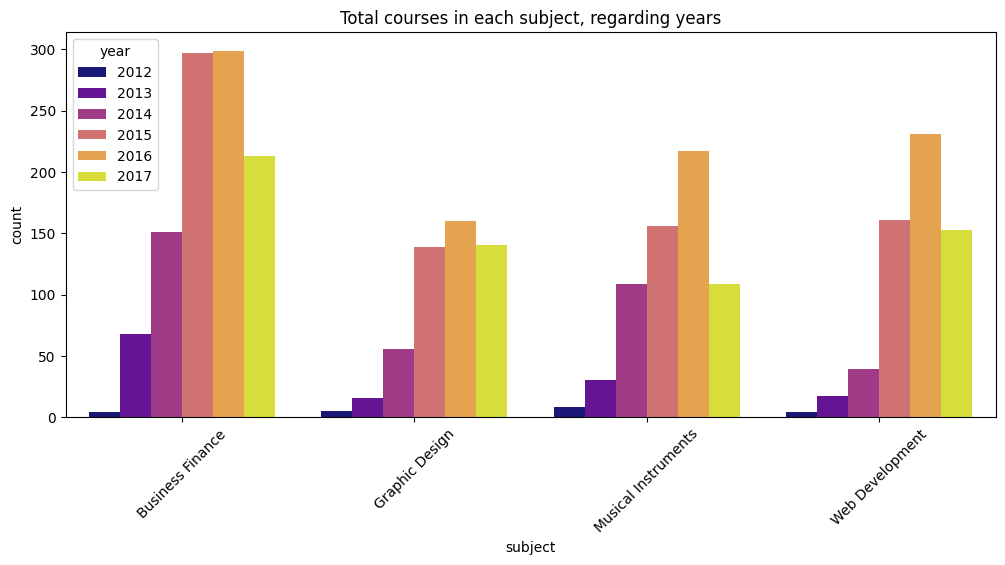

In [81]:
plt.figure(figsize=(12,5))
plt.xticks(rotation= 45)
sns.countplot(data=df,
              x='subject',
              hue='year',
              palette='plasma')
plt.title('Total courses in each subject, regarding years')

In [82]:
px.bar(
    data_frame=df.groupby(['subject','year'])['num_subscribers'].sum().reset_index(),
    x='subject',
    y='num_subscribers',
    color='year',
    title='Num Subscribers in each subject, regarding years'
)

In [83]:
pd.pivot_table(data=df,
               index='subject',
               columns='content_duration_cat',
               values='num_subscribers',
               aggfunc=['count'])

C:\Users\abdal\AppData\Local\Temp\ipykernel_14456\1278029593.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data=df,


count                               
content_duration_cat 0 : 1 1 : 3 3 : 7 7 : 12 12 : 20 +20
subject                                                  
Business Finance       292   449   208     45      18  20
Graphic Design         178   193    98     33      12   2
Musical Instruments    181   298   124     23       2   1
Web Development        144   233   159     41      21   7

In [84]:
px.bar(data_frame=df,
       x='year',
       y='profit',
       color='subject',
       barmode='group',
       title='Total profit for each year, regarding subject')

In [85]:
px.bar(
    data_frame=df.groupby(['subject','price_cat'])['num_subscribers'].sum().reset_index(),
    x='subject',
    y='num_subscribers',
    color='price_cat',
    barmode='group',
    title='Regarding price category, What are the number of subscribers in each subject?'
)

C:\Users\abdal\AppData\Local\Temp\ipykernel_14456\4289052053.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_frame=df.groupby(['subject','price_cat'])['num_subscribers'].sum().reset_index(),


### ----------------------------------------------------------------------

In [86]:
df.sample(2)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2016-12-27,978850,Learn by Example : ReactJS,https://www.udemy.com/learn-by-example-reactjs/,True,50,1496,37,74,Beginner Level,7.5,Web Development,2016-12-27,2016,4,December,74800,7 : 12,20:50
2016-10-19,986832,Adobe Photoshop CC Introduction,https://www.udemy.com/adobe-photoshop-cc-intro...,True,30,1,0,55,Beginner Level,4.5,Graphic Design,2016-10-19,2016,4,October,30,3 : 7,20:50


## **Time-Series Analysis**

In [87]:
## df.set_index(df['published'] , inplace=True)

In [88]:
df.head(2)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2017-01-18,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,Business Finance,2017-01-18,2017,1,January,429400,1 : 3,170:200
2016-12-19,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,Business Finance,2016-12-19,2016,4,December,97830,1 : 3,20:50


In [89]:
df.index

DatetimeIndex(['2017-01-18', '2016-12-19', '2017-05-30', '2016-12-13',
               '2015-05-28', '2017-04-18', '2016-10-18', '2016-02-03',
               '2016-03-16', '2017-04-28',
               ...
               '2017-02-18', '2016-09-27', '2015-11-09', '2015-11-29',
               '2015-11-19', '2016-10-10', '2016-06-14', '2017-03-10',
               '2016-08-11', '2014-09-28'],
              dtype='datetime64[ns]', name='published', length=2782, freq=None)

In [90]:
df.loc['2017']['profit'].mean().round(2)

np.float64(50369.01)

In [91]:
df.sort_index().loc['2017-01-20' : '2017-01-25']

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2017-01-20,1079624,HTML and CSS for Absolute Beginners,https://www.udemy.com/html-and-css-for-absolut...,False,0,4410,52,26,All Levels,3.000000,Web Development,2017-01-20,2017,1,January,0,1 : 3,free
2017-01-20,981600,HTML and CSS BootCamp for Beginners,https://www.udemy.com/html-and-css-bootcamp-fo...,True,30,1777,35,48,Beginner Level,6.500000,Web Development,2017-01-20,2017,1,January,53310,3 : 7,20:50
2017-01-20,1021104,Aprenda a Investir seu Dinheiro,https://www.udemy.com/aprenda-a-investir-seu-d...,True,85,150,28,19,All Levels,2.500000,Business Finance,2017-01-20,2017,1,January,12750,1 : 3,80:110
2017-01-23,1076920,Stock Market investment: Practical Accounting,https://www.udemy.com/stock-market-investment-...,True,125,1120,6,43,Beginner Level,3.000000,Business Finance,2017-01-23,2017,1,January,140000,1 : 3,110:140
2017-01-23,1045886,Learn Acoustic Guitar for Worship,https://www.udemy.com/learn-acoustic-guitar-fo...,True,40,86,18,26,Beginner Level,2.000000,Musical Instruments,2017-01-23,2017,1,January,3440,1 : 3,20:50
2017-01-23,1056848,Joomla for Beginners - Learn how to build a we...,https://www.udemy.com/joomla-for-beginners-bui...,True,95,583,7,35,Beginner Level,3.500000,Web Development,2017-01-23,2017,1,January,55385,3 : 7,80:110
2017-01-23,1077836,Ecover Mastery in 30 Minutes with NO photoshop...,https://www.udemy.com/ecover-mastery-in-30-min...,True,20,1,0,10,Beginner Level,0.633333,Graphic Design,2017-01-23,2017,1,January,20,0 : 1,1:20
2017-01-23,1022796,Trading for winning,https://www.udemy.com/charting-for-beginners-f...,True,200,168,7,27,All Levels,2.000000,Business Finance,2017-01-23,2017,1,January,33600,1 : 3,170:200
2017-01-23,1068986,How To Profit From Stock Market Volatility,https://www.udemy.com/how-to-trade-stock-marke...,False,0,1736,36,11,All Levels,0.600000,Business Finance,2017-01-23,2017,1,January,0,0 : 1,free


In [106]:
## resample() = Time based grouping

df.resample('YE').agg({
    'profit' : 'mean',
    'num_subscribers' : 'sum',
    'num_reviews' : 'sum'
}).round(2)

,profit,num_subscribers,num_reviews
published,,,
2012-12-31,38548.57,19286,487
2013-12-31,52127.33,115817,3213
2014-12-31,36093.14,280439,5715
2015-12-31,76720.90,822446,15385
2016-12-31,59525.89,780393,17796
2017-12-31,50369.01,443049,7154


In [107]:
df.resample('ME').agg(
    profit_mean = ('profit' , 'mean'),
    Total_subscribers = ('num_subscribers' , 'sum'),
    Total_reviews = ('num_reviews' , 'sum')
).round(2)

,profit_mean,Total_subscribers,Total_reviews
published,,,
2012-01-31,4165.00,119,8
2012-02-29,151300.00,3026,60
2012-03-31,NaN,0,0
2012-04-30,7440.00,372,21
2012-05-31,23287.50,1863,44
...,...,...,...
2017-03-31,47018.39,64898,1253
2017-04-30,55283.24,63954,828
2017-05-31,43397.66,89587,1442


In [94]:
df.resample('D')['profit'].sum()

published
2012-01-26     4165
2012-01-27        0
2012-01-28        0
2012-01-29        0
2012-01-30        0
              ...  
2017-07-02        0
2017-07-03    63660
2017-07-04     1485
2017-07-05      200
2017-07-06    13765
Freq: D, Name: profit, Length: 1989, dtype: int64

## =Profit

### What is the total profit made in each year?

In [95]:
df.resample('Y').agg(
    Total_Profit = ('profit' , 'sum')
)

C:\Users\abdal\AppData\Local\Temp\ipykernel_14456\2281818484.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample('Y').agg(


,Total_Profit
published,
2012-12-31,809520
2013-12-31,6828680
2014-12-31,12813065
2015-12-31,57770840
2016-12-31,53989980
2017-12-31,30976940


In [109]:
px.line(
    x=df.resample('YE')['profit'].sum().index.year,
    y=df.resample('YE')['profit'].sum().values,
    title='Total Profit Made in Each Year' ,
    labels={
        'x' : 'Year',
        'y' : 'Total Profit'
    },
    line_shape='spline'   
)

#### What is Monthly total profit over time?

In [97]:
df_grouped = df.resample('ME')['profit'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x = 'published',
    y = 'profit',
    labels={
        'published' : 'Date',
        'profit' : 'Total Profit ($)'
    },
    title='Monthly total profit over time',
    markers=True,
    line_shape = 'spline'
)

### What is the total profit made in each Month, regarding course levels?

In [110]:
df_grouped = df.groupby([pd.Grouper(key='published' , freq='ME') , 'level'])['profit'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x='published',
    y='profit',
    color='level',
    labels={
        'profit' : 'Total Profit ($)',
        'published' : 'Date',
        'level' : 'Course Levels'
    },
    title='Monthly Total Profit by course levels Over Time',
    category_orders={
        'level' : ['Beginner Level' , 'Intermediate Level' , 'Expert Level' , 'All Levels']},
        markers=True,
        line_shape= 'spline'
)

### What is the total profit made in each Month, regarding Subject?

In [99]:
df_grouped = df.groupby([pd.Grouper(key='published' , freq='ME') , 'subject'])['profit'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x='published',
    y='profit',
    color='subject',
    labels={
        'published' : 'Date',
        'profit' : 'Total Profit ($)'
    },
    title='Monthly Total Profit by Subject Over Time',
    markers= True,
    line_shape='spline'
)

## =Number of Sbuscribers


#### What is the total number of subscribers in each year?

In [100]:
px.line(
    data_frame=df.resample('YE')['num_subscribers'].sum().reset_index(),
    x = df.resample('YE')['num_subscribers'].sum().index.year,
    y = 'num_subscribers',
    labels={
        'x' : 'Date',
        'num_subscribers' : 'Total Number of Subscribers'
    },
    markers= True,
    title='Total Number of Subscribers in each year',
    line_shape= 'spline'
)

#### What is the Monthly total subscribers over time?

In [101]:
df_grouped = df.resample('ME')['num_subscribers'].sum().reset_index()

px.line(
    data_frame= df_grouped,
    x = 'published',
    y = 'num_subscribers',
    markers=True,
    labels={
        'published' : 'Date',
        'num_subscribers' : 'Total Number of Subscribers'
    },
    title='Monthly total number of subscribers over time',
    line_shape= 'spline'


)

#### Regarding subject, What is the Monthly Total Subscribers over time?

In [102]:
df_grouped = df.groupby([pd.Grouper(key='published' , freq='ME') , 'subject'])['num_subscribers'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x = 'published' ,
    y = 'num_subscribers',
    color = 'subject',
    title='Monthly total number of subscribers by subject over time',
    markers= True,
    labels={
        'published' : 'Date',
        'num_subscribers' : 'Total Subscribers'
    },
    line_shape= 'spline'
)

#### Regarding Course Levels, What is the Monthly Total Subscribers over time?

In [103]:
df_grouped = df.groupby([pd.Grouper(key='published' , freq='ME') , 'level'])['num_subscribers'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x = 'published' ,
    y = 'num_subscribers',
    color = 'level',
    title='Monthly total number of subscribers by Course Levels over time',
    markers= True,
    labels={
        'published' : 'Date',
        'num_subscribers' : 'Total Subscribers',
        'level' : 'Course Levels'
    },
    category_orders={
        'level' : ['Beginner Level' , 'Intermediate Level' , 'Expert Level' , 'All Levels']
    },
    line_shape= 'spline'
)

In [104]:
df.head(3)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2017-01-18,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,Business Finance,2017-01-18,2017,1,January,429400,1 : 3,170:200
2016-12-19,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,Business Finance,2016-12-19,2016,4,December,97830,1 : 3,20:50
2017-05-30,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,Business Finance,2017-05-30,2017,2,May,232845,1 : 3,80:110


## Saving Dataset

In [105]:
df.to_csv('udemy_courses_cleaned.csv')

In [112]:
df.sample(4)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published,year,quarter,month,profit,content_duration_cat,price_cat
published,,,,,,,,,,,,,,,,,,
2017-07-03,1232390,Corporate Ethics,https://www.udemy.com/corporate-ethics/,True,100,0,0,13,Beginner Level,3.5,Business Finance,2017-07-03,2017,3,July,0,3 : 7,80:110
2015-10-15,608090,Adobe Illustrator For Beginners: Design A Typo...,https://www.udemy.com/illustratorforbeginners/,True,30,276,54,27,Beginner Level,1.5,Graphic Design,2015-10-15,2015,4,October,8280,1 : 3,20:50
2017-03-08,1124280,PHP Tutorial: Learn PHP Basic Programming for ...,https://www.udemy.com/php-tutorial-beginners/,True,20,2510,21,23,Beginner Level,1.5,Web Development,2017-03-08,2017,1,March,50200,1 : 3,1:20
2016-06-06,867440,"Bitcoin: el futuro del dinero, hoy",https://www.udemy.com/bitcoin-el-futuro-del-di...,True,200,57,22,19,Intermediate Level,3.0,Business Finance,2016-06-06,2016,2,June,11400,1 : 3,170:200
